# Validating UMI counts in Nuclei bins

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import anndata
import geopandas as gpd
import scanpy as sc
import pickle

from tifffile import imread, imwrite
from csbdeep.utils import normalize
from stardist.models import StarDist2D
from shapely.geometry import Polygon, Point
from shapely.geometry import box
from scipy import sparse
from matplotlib.colors import ListedColormap

## plotting funcs

In [154]:
# General image plotting functions
def plot_mask_and_save_image(title, gdf, img, cmap, output_name=None, bbox=None):
    if bbox is not None:
        # Crop the image to the bounding box
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    # Plot options
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the cropped image
    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    # Create filtering polygon
    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])
        # Filter for polygons in the box
        intersects_bbox = gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = gdf[intersects_bbox]
    else:
        filtered_gdf=gdf

    # Plot the filtered polygons on the second axis
    filtered_gdf.plot(cmap=cmap, ax=axes[1])
    axes[1].axis('off')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))


    # Save the plot if output_name is provided
    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')  # Use bbox_inches='tight' to include the legend
    else:
        plt.show()

def plot_gene_and_save_image(title, gdf, gene, img, adata, bbox=None, output_name=None):

    if bbox is not None:
        # Crop the image to the bounding box
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    # Plot options
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the cropped image
    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    # Create filtering polygon
    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])


    # Find a gene of interest and merge with the geodataframe
    gene_expression = adata[:, gene].to_df()
    gene_expression['id'] = gene_expression.index
    merged_gdf = gdf.merge(gene_expression, left_on='id', right_on='id')

    if bbox is not None:
        # Filter for polygons in the box
        intersects_bbox = merged_gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = merged_gdf[intersects_bbox]
    else:
        filtered_gdf = merged_gdf

    # Plot the filtered polygons on the second axis
    filtered_gdf.plot(column=gene, cmap='inferno', legend=True, ax=axes[1])
    axes[1].set_title(gene)
    axes[1].axis('off')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))

    # Save the plot if output_name is provided
    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')  # Use bbox_inches='tight' to include the legend
    else:
        plt.show()

def plot_clusters_and_save_image(title, gdf, img, adata, bbox=None, color_by_obs=None, output_name=None, color_list=None):
    color_list=["#7f0000","#808000","#483d8b","#008000","#bc8f8f","#008b8b","#4682b4","#000080","#d2691e","#9acd32","#8fbc8f","#800080","#b03060","#ff4500","#ffa500","#ffff00","#00ff00","#8a2be2","#00ff7f","#dc143c","#00ffff","#0000ff","#ff00ff","#1e90ff","#f0e68c","#90ee90","#add8e6","#ff1493","#7b68ee","#ee82ee"]
    if bbox is not None:
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])

    unique_values = adata.obs[color_by_obs].astype('category').cat.categories
    num_categories = len(unique_values)

    if color_list is not None and len(color_list) >= num_categories:
        custom_cmap = ListedColormap(color_list[:num_categories], name='custom_cmap')
    else:
        # Use default tab20 colors if color_list is insufficient
        tab20_colors = plt.cm.tab20.colors[:num_categories]
        custom_cmap = ListedColormap(tab20_colors, name='custom_tab20_cmap')

    merged_gdf = gdf.merge(adata.obs[color_by_obs].astype('category'), left_on='id', right_index=True)

    if bbox is not None:
        intersects_bbox = merged_gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = merged_gdf[intersects_bbox]
    else:
        filtered_gdf = merged_gdf

    # Plot the filtered polygons on the second axis
    plot = filtered_gdf.plot(column=color_by_obs, cmap=custom_cmap, ax=axes[1], legend=True)
    axes[1].set_title(color_by_obs)
    legend = axes[1].get_legend()
    legend.set_bbox_to_anchor((1.05, 1))
    axes[1].axis('off')

    # Move legend outside the plot
    plot.get_legend().set_bbox_to_anchor((1.25, 1))

    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')
    else:
        plt.show()

# Plotting function for nuclei area distribution
def plot_nuclei_area(gdf,area_cut_off):
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    # Plot the histograms
    axs[0].hist(gdf['area'], bins=50, edgecolor='black')
    axs[0].set_title('Nuclei Area')

    axs[1].hist(gdf[gdf['area'] < area_cut_off]['area'], bins=50, edgecolor='black')
    axs[1].set_title('Nuclei Area Filtered:'+str(area_cut_off))

    plt.tight_layout()
    plt.show()

# Total UMI distribution plotting function
def total_umi(adata_, cut_off):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot
    axs[0].boxplot(adata_.obs["total_counts"], vert=False, widths=0.7, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    axs[0].set_title('Total Counts')

    # Box plot after filtering
    axs[1].boxplot(adata_.obs["total_counts"][adata_.obs["total_counts"] > cut_off], vert=False, widths=0.7, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    axs[1].set_title('Total Counts > ' + str(cut_off))

    # Remove y-axis ticks and labels
    for ax in axs:
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()


## Making barcode level df

from Binning Visum HD Gene Expression Data vignette

In [155]:
# Load Visium HD data
dir_base = "/Users/jessica/Documents/City of Hope/CAR-T/data/Raw/BANOSSM_SSM0015_1_PR_Whole_C1_VISHD_F07839_22WJCYLT3/outs/binned_outputs/square_002um"
raw_h5_file = dir_base + '/filtered_feature_bc_matrix.h5'
adata = sc.read_10x_h5(raw_h5_file)

# Load the Spatial Coordinates
tissue_position_file = dir_base+'/spatial/tissue_positions.parquet'
df_tissue_positions=pd.read_parquet(tissue_position_file)

#Set the index of the dataframe to the barcodes
df_tissue_positions = df_tissue_positions.set_index('barcode')

# Create an index in the dataframe to check joins
df_tissue_positions['index']=df_tissue_positions.index

# Adding the tissue positions to the meta data
adata.obs =  pd.merge(adata.obs, df_tissue_positions, left_index=True, right_index=True)

# Create a GeoDataFrame from the DataFrame of coordinates
geometry = [Point(xy) for xy in zip(df_tissue_positions['pxl_col_in_fullres'], df_tissue_positions['pxl_row_in_fullres'])]
gdf_coordinates = gpd.GeoDataFrame(df_tissue_positions, geometry=geometry)


anndata.py (1758): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1758): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [156]:
with open("/Users/jessica/Documents/City of Hope/CAR-T/data/cell_segmentation/F07839/model_output/F07839_polys.pkl", "rb") as f:
    polys = pickle.load(f)

In [157]:
geometries = []
for nuclei in range(len(polys['coord'])):
    coords = [(y, x) for x, y in zip(polys['coord'][nuclei][0], polys['coord'][nuclei][1])]
    geometries.append(Polygon(coords))

gdf = gpd.GeoDataFrame(geometry=geometries)
gdf['id'] = [f"ID_{i+1}" for i, _ in enumerate(gdf.index)]

In [158]:
# Perform a spatial join to check which coordinates are in a cell nucleus
result_spatial_join = gpd.sjoin(gdf_coordinates, gdf, how='left', predicate='within')

# Identify nuclei associated barcodes and find barcodes that are in more than one nucleus
result_spatial_join['is_within_polygon'] = ~result_spatial_join['index_right'].isna()
barcodes_in_overlaping_polygons = pd.unique(result_spatial_join[result_spatial_join.duplicated(subset=['index'])]['index'])
result_spatial_join['is_not_in_an_polygon_overlap'] = ~result_spatial_join['index'].isin(barcodes_in_overlaping_polygons)

# Remove barcodes in overlapping nuclei
barcodes_in_one_polygon = result_spatial_join[result_spatial_join['is_within_polygon'] & result_spatial_join['is_not_in_an_polygon_overlap']]

# The AnnData object is filtered to only contain the barcodes that are in non-overlapping polygon regions
filtered_obs_mask = adata.obs_names.isin(barcodes_in_one_polygon['index'])
filtered_adata = adata[filtered_obs_mask,:]

# Add the results of the point spatial join to the Anndata object
filtered_adata.obs =  pd.merge(filtered_adata.obs, barcodes_in_one_polygon[['index','geometry','id','is_within_polygon','is_not_in_an_polygon_overlap']], left_index=True, right_index=True)

anndata.py (1758): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [159]:
filtered_adata.obs.head()

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,index_x,index_y,geometry,id,is_within_polygon,is_not_in_an_polygon_overlap
s_002um_02058_00301-1,1,2058,301,7797.253775,9176.010758,s_002um_02058_00301-1,s_002um_02058_00301-1,POINT (9176.011 7797.254),ID_79621,True,True
s_002um_00700_02130-1,1,700,2130,3847.420700,3854.984428,s_002um_00700_02130-1,s_002um_00700_02130-1,POINT (3854.984 3847.421),ID_41459,True,True
s_002um_03246_01880-1,1,3246,1880,11253.528541,4583.091191,s_002um_03246_01880-1,s_002um_03246_01880-1,POINT (4583.091 11253.529),ID_126565,True,True
s_002um_03000_02634-1,1,3000,2634,10538.122805,2389.644029,s_002um_03000_02634-1,s_002um_03000_02634-1,POINT (2389.644 10538.123),ID_110064,True,True
s_002um_01050_01530-1,1,1050,1530,4865.371734,5600.490257,s_002um_01050_01530-1,s_002um_01050_01530-1,POINT (5600.49 4865.372),ID_44112,True,True


In [160]:
# add UMI counts to the table
filtered_adata.obs['umi'] = np.ravel(filtered_adata.X.sum(axis=1))

In [161]:
filtered_adata.obs.head(10)

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,index_x,index_y,geometry,id,is_within_polygon,is_not_in_an_polygon_overlap,umi
s_002um_02058_00301-1,1,2058,301,7797.253775,9176.010758,s_002um_02058_00301-1,s_002um_02058_00301-1,POINT (9176.011 7797.254),ID_79621,True,True,8.0
s_002um_00700_02130-1,1,700,2130,3847.420700,3854.984428,s_002um_00700_02130-1,s_002um_00700_02130-1,POINT (3854.984 3847.421),ID_41459,True,True,9.0
s_002um_03246_01880-1,1,3246,1880,11253.528541,4583.091191,s_002um_03246_01880-1,s_002um_03246_01880-1,POINT (4583.091 11253.529),ID_126565,True,True,16.0
s_002um_03000_02634-1,1,3000,2634,10538.122805,2389.644029,s_002um_03000_02634-1,s_002um_03000_02634-1,POINT (2389.644 10538.123),ID_110064,True,True,2.0
s_002um_01050_01530-1,1,1050,1530,4865.371734,5600.490257,s_002um_01050_01530-1,s_002um_01050_01530-1,POINT (5600.49 4865.372),ID_44112,True,True,11.0
s_002um_01596_01155-1,1,1596,1155,6453.551543,6691.550089,s_002um_01596_01155-1,s_002um_01596_01155-1,POINT (6691.55 6453.552),ID_57222,True,True,9.0
s_002um_02109_01204-1,1,2109,1204,7945.861717,6549.184081,s_002um_02109_01204-1,s_002um_02109_01204-1,POINT (6549.184 7945.862),ID_76732,True,True,1.0
s_002um_02503_02060-1,1,2503,2060,9092.224200,4059.222944,s_002um_02503_02060-1,s_002um_02503_02060-1,POINT (4059.223 9092.224),ID_95324,True,True,20.0
s_002um_02831_00401-1,1,2831,401,10045.920652,8885.373330,s_002um_02831_00401-1,s_002um_02831_00401-1,POINT (8885.373 10045.921),ID_121135,True,True,57.0
s_002um_01302_01082-1,1,1302,1082,5598.296745,6903.806970,s_002um_01302_01082-1,s_002um_01302_01082-1,POINT (6903.807 5598.297),ID_57707,True,True,1.0


In [146]:
filtered_adata.n_obs

2209716

## Nucleus level df

In [180]:
file_path = "/Users/jessica/Documents/City of Hope/CAR-T/data/cell_segmentation/F07839/F07839_grouped_filtered_adata.h5ad"
adata = sc.read_h5ad(file_path)

adata.obs.head()


,id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
ID_100000,ID_100000,242,5.493061,259.0,5.560682,25.868726,45.173745,83.783784,100.0
ID_100001,ID_100001,50,3.931826,54.0,4.007333,100.000000,100.000000,100.000000,100.0
ID_100002,ID_100002,32,3.496508,33.0,3.526361,100.000000,100.000000,100.000000,100.0
ID_100003,ID_100003,42,3.761200,42.0,3.761200,100.000000,100.000000,100.000000,100.0
ID_100004,ID_100004,21,3.091042,21.0,3.091042,100.000000,100.000000,100.000000,100.0


## Estimating microns to Pixel

In [164]:
df_tissue_positions.head()

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,index
barcode,,,,,,
s_002um_00000_00000-1,1,0,0,1810.499918,10050.921319,s_002um_00000_00000-1
s_002um_00000_00001-1,1,0,1,1810.500231,10048.012280,s_002um_00000_00001-1
s_002um_00000_00002-1,1,0,2,1810.500544,10045.103242,s_002um_00000_00002-1
s_002um_00000_00003-1,1,0,3,1810.500857,10042.194204,s_002um_00000_00003-1
s_002um_00000_00004-1,1,0,4,1810.501170,10039.285166,s_002um_00000_00004-1


In [167]:
# sort and compute pixel distance between adjacent barcodes
df_tissue_positions_sorted = df_tissue_positions.sort_values(by=['array_row', 'array_col'])
df_same_row = df_tissue_positions_sorted[df_tissue_positions_sorted['array_row'] == df_tissue_positions_sorted['array_row'].iloc[0]]

# Get the pixel x-coords of two neighboring barcodes
x1 = df_same_row.iloc[0]['pxl_col_in_fullres']
x2 = df_same_row.iloc[1]['pxl_col_in_fullres']
pixel_distance = abs(x2 - x1)
pixel_distance

2.9090382016474905

In [182]:
microns_per_pixel = 2.0 / pixel_distance
print(f"Estimated microns per pixel: {microns_per_pixel:.4f}")

# bin size should be around 2.91

Estimated microns per pixel: 0.6875


## Testing Plotting nuclei with barcode bins

In [107]:
# Load the image file
path = '/Users/jessica/Documents/City of Hope/CAR-T/data/images_for_alignments/121724-121924_RL_mRT_TMA4#1_TMA5#1/hne/121724_RL_mRT_TMA4_Slide_1_07839.tif'
img = imread(path)

2949323654.py (29): No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


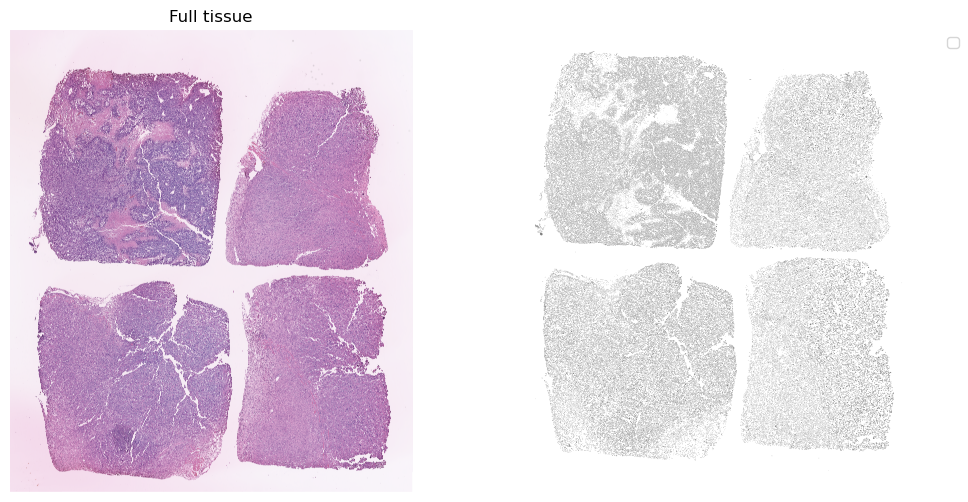

In [100]:
dir_base = "/Users/jessica/Documents/City of Hope/"
cmap=ListedColormap(['grey'])
plot_mask_and_save_image(
    title="Full tissue",
    gdf=gdf,
    bbox= None,
    cmap=cmap,
    img=img,
    output_name=dir_base + "image_mask.full.tif"
)

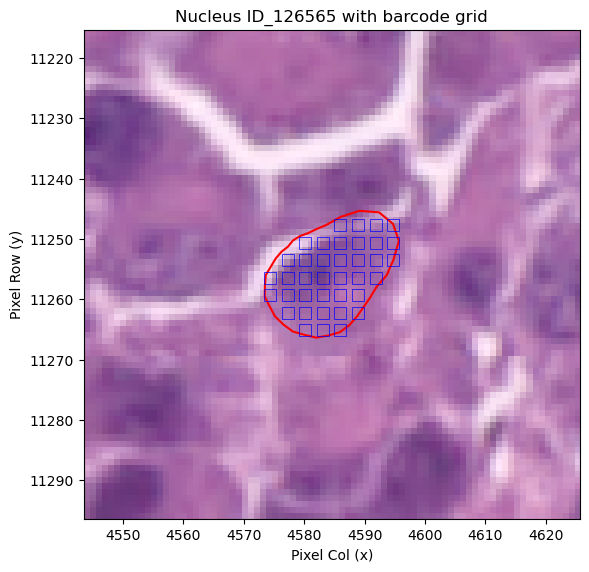

In [136]:
# nucleus ID and get all the barcodes in it
target_nucleus_id = 'ID_126565'
barcodes_in_nucleus = filtered_adata.obs[filtered_adata.obs['id'] == target_nucleus_id]
bin_size = 4

# get the nucleous polygon
nucleus_poly = gdf[gdf['id'] == target_nucleus_id].geometry.values[0]

# define a bounding box around the nucleus for plotting (add buffer)
buffer = 30 # pixels ?
minx, miny, maxx, maxy = nucleus_poly.bounds
bbox = (minx - buffer, maxx + buffer, miny - buffer, maxy + buffer)

# crop HnE
cropped_img = img[int(bbox[2]):int(bbox[3]), int(bbox[0]):int(bbox[1])]

# plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cropped_img,
          extent=[bbox[0], bbox[1], bbox[3], bbox[2]])

# plot the nucleus polygon
gpd.GeoSeries([nucleus_poly]).plot(ax=ax, facecolor='none', edgecolor='red', linewidth= 1.5)

# plot barcode rectangles (2μm x 2μm centered on pxl coords)
for idx, row in barcodes_in_nucleus.iterrows():
    '''
    x = bin_size * round(row['pxl_col_in_fullres'] / bin_size)
    y = bin_size * round(row['pxl_row_in_fullres'] / bin_size)
    rect = Rectangle((x - bin_size / 2, y - bin_size / 2), bin_size, bin_size,
                     linewidth=0.3, edgecolor='blue', facecolor='blue', alpha=0.3)
    '''                 
    # for squares instead 
    x_center = row['pxl_col_in_fullres']
    y_center = row['pxl_row_in_fullres']
    rect = patches.Rectangle((x_center - 1, y_center - 1), 2, 2,
                             linewidth=0.5, edgecolor='blue', facecolor='none')
                            
    ax.add_patch(rect)

# axis
ax.set_xlim(bbox[0], bbox[1])
ax.set_ylim(bbox[3], bbox[2])  # y-axis inverted for image coords
ax.set_title(f"Nucleus {target_nucleus_id} with barcode grid")
ax.set_xlabel("Pixel Col (x)")
ax.set_ylabel("Pixel Row (y)")
plt.tight_layout()
plt.show()


In [124]:
barcodes_in_nucleus.count()

in_tissue                       38
array_row                       38
array_col                       38
pxl_row_in_fullres              38
pxl_col_in_fullres              38
index_x                         38
index_y                         38
geometry                        38
id                              38
is_within_polygon               38
is_not_in_an_polygon_overlap    38
umi                             38
dtype: int64

## Plotting function with UMI count output

In [175]:
def plot_nucleus_with_barcodes(nucleus_id, buffer):
    # nucleus ID and get all the barcodes in it
    target_nucleus_id = nucleus_id
    barcodes_in_nucleus = filtered_adata.obs[filtered_adata.obs['id'] == target_nucleus_id]
    bin_size = 2.91

    # get the nucleous polygon
    nucleus_poly = gdf[gdf['id'] == target_nucleus_id].geometry.values[0]

    # define a bounding box around the nucleus for plotting (add buffer)
    buffer = buffer # pixels ?
    minx, miny, maxx, maxy = nucleus_poly.bounds
    bbox = (minx - buffer, maxx + buffer, miny - buffer, maxy + buffer)

    # crop HnE
    cropped_img = img[int(bbox[2]):int(bbox[3]), int(bbox[0]):int(bbox[1])]

    # plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cropped_img,
              extent=[bbox[0], bbox[1], bbox[3], bbox[2]])

    # plot the nucleus polygon
    gpd.GeoSeries([nucleus_poly]).plot(ax=ax, facecolor='none', edgecolor='red', linewidth= 1.5)

    # plot barcode rectangles (2μm x 2μm centered on pxl coords)
    for idx, row in barcodes_in_nucleus.iterrows():
        ''' # for transparent grid
        x = bin_size * round(row['pxl_col_in_fullres'] / bin_size)
        y = bin_size * round(row['pxl_row_in_fullres'] / bin_size)
        rect = Rectangle((x - bin_size / 2, y - bin_size / 2), bin_size, bin_size,
                         linewidth=0.3, edgecolor='blue', facecolor='blue', alpha=0.3)
        ''' # for outlined squares 
        x_center = row['pxl_col_in_fullres']
        y_center = row['pxl_row_in_fullres']
        rect = patches.Rectangle((x_center - 1, y_center - 1), 2.91, 2.91,
                                 linewidth=0.5, edgecolor='blue', facecolor='none')
                                
        ax.add_patch(rect)

    # axis
    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[3], bbox[2])  # y-axis inverted for image coords
    ax.set_title(f"Nucleus {target_nucleus_id} with barcode grid")
    ax.set_xlabel("Pixel Col (x)")
    ax.set_ylabel("Pixel Row (y)")
    plt.tight_layout()
    plt.show()

    
    # create and return a dataframe summarizing UMIs per barcode
    umi_df = barcodes_in_nucleus[['id', 'umi']].copy()
    umi_df = umi_df.rename_axis("barcode").reset_index()
    total_umi = umi_df['umi'].sum()
    umi_df.loc[len(umi_df.index)] = ["TOTAL", total_umi, ""]

    return umi_df


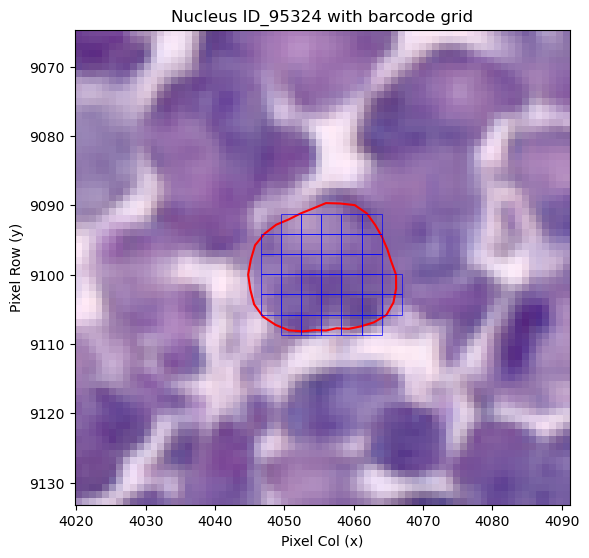

,barcode,id,umi
0,s_002um_02503_02060-1,ID_95324,20.0
1,s_002um_02503_02061-1,ID_95324,37.0
2,s_002um_02508_02061-1,ID_95324,38.0
3,s_002um_02507_02058-1,ID_95324,16.0
4,s_002um_02505_02062-1,ID_95324,28.0
5,s_002um_02503_02063-1,ID_95324,23.0
6,s_002um_02507_02064-1,ID_95324,11.0
7,s_002um_02508_02062-1,ID_95324,27.0
8,s_002um_02507_02059-1,ID_95324,22.0
9,s_002um_02505_02059-1,ID_95324,19.0


In [176]:
# test
plot_nucleus_with_barcodes("ID_95324", 25)

In [181]:
'''
Check if this matches with the grouped filtered adata UMI count
'''

nucleus_id = "ID_95324"
umi = adata.obs.loc[nucleus_id, "total_counts"]
print(f"Total UMI count for {nucleus_id}: {umi}")

Total UMI count for ID_95324: 882.0
